# Data-Driven Time-Stepping with an LSTM in the POD Reduced Space

The `POD` notebook showed that 35 modes are enough to represent the von Kármán vortex street with less than 1 % mean error. Each video frame therefore reduces to a vector of 35 **temporal coefficients** $\mathbf{a}(t) \in \mathbb{R}^{35}$ — a dramatic compression from the original $32{,}768$ pixels.

This compressed representation opens the door to **data-driven time-stepping**: instead of simulating the full fluid equations, we learn a map

$$\mathbf{a}(t) \xrightarrow{\;f_\theta\;} \mathbf{a}(t+\Delta t)$$

directly from data. Predictions of $\mathbf{a}$ can then be lifted back to pixel space via the spatial modes $\boldsymbol{\Phi}$:

$$\tilde{\mathbf{x}}(t) = \boldsymbol{\Phi}\,\mathbf{a}(t)$$

We choose a **Long Short-Term Memory (LSTM)** network as $f_\theta$ because it is designed to model sequential dependencies. Even though each input is a single time step here (the map is Markovian), the LSTM's gating mechanism makes it robust to the quasi-periodic, slightly irregular dynamics of the vortex shedding.

## 1. Background: POD-ROM Time-Stepping

### POD projection

Given the snapshot matrix $\mathbf{X} \in \mathbb{R}^{N_x \times N_t}$ and its economy SVD $\mathbf{X} = \mathbf{U}\boldsymbol{\Sigma}\mathbf{V}^\top$, we define the **reduced basis** $\boldsymbol{\Phi} = \mathbf{U}_{:,1:r} \in \mathbb{R}^{N_x \times r}$ and the **reduced coordinates**:

$$\mathbf{a} = \boldsymbol{\Phi}^\top \mathbf{X} \in \mathbb{R}^{r \times N_t}$$

### LSTM equations

At each step the LSTM processes the input $\mathbf{a}(t)$ through four gates:

$$\mathbf{f}_t = \sigma(\mathbf{W}_f [\mathbf{h}_{t-1}, \mathbf{a}_t] + \mathbf{b}_f) \quad \text{(forget gate)}$$
$$\mathbf{i}_t = \sigma(\mathbf{W}_i [\mathbf{h}_{t-1}, \mathbf{a}_t] + \mathbf{b}_i) \quad \text{(input gate)}$$
$$\mathbf{g}_t = \tanh(\mathbf{W}_g [\mathbf{h}_{t-1}, \mathbf{a}_t] + \mathbf{b}_g) \quad \text{(cell update)}$$
$$\mathbf{c}_t = \mathbf{f}_t \odot \mathbf{c}_{t-1} + \mathbf{i}_t \odot \mathbf{g}_t \quad \text{(cell state)}$$
$$\mathbf{h}_t = \mathbf{o}_t \odot \tanh(\mathbf{c}_t) \quad \text{(hidden state / output)}$$

The hidden state $\mathbf{h}_t \in \mathbb{R}^{128}$ is passed through a linear projection layer to produce $\hat{\mathbf{a}}(t+1) \in \mathbb{R}^{35}$.

### Training objective

We minimise the **mean squared error** between predicted and true next-step coefficients:

$$\mathcal{L}(\theta) = \frac{1}{N} \sum_{t=1}^{N} \left\| f_\theta(\mathbf{a}(t)) - \mathbf{a}(t+1) \right\|^2$$

## 2. Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 3. Loading Data and SVD Reduction

We repeat the SVD step from the `POD` notebook to obtain the reduced basis $\boldsymbol{\Phi}$ and the temporal coefficients $\mathbf{a}$. Using $r = 35$ modes balances reconstruction accuracy against the complexity of the regression problem: a smaller $r$ would be faster to train but less accurate; a larger $r$ would slow training with diminishing returns.

In [2]:
frames_array = np.load('frames_array.npy')
N_t, H, W = frames_array.shape

flattened_frames = frames_array.reshape(N_t, -1).T
print(f"Snapshot matrix shape: {flattened_frames.shape}")

U, S, Vt = np.linalg.svd(flattened_frames, full_matrices=False)

r = 35
phi = U[:, :r]
a   = phi.T @ flattened_frames

print(f"Reduced basis shape : {phi.shape}")
print(f"Coefficients shape  : {a.shape}  (r × N_t)")

Snapshot matrix shape: (32768, 252)
Reduced basis shape : (32768, 35)
Coefficients shape  : (35, 252)  (r × N_t)


## 4. Building the Sequence Dataset

We form input–output pairs by shifting the coefficient matrix by one time step:

$$\text{input}_t = \mathbf{a}(:,\, t), \qquad \text{output}_t = \mathbf{a}(:,\, t+1), \quad t = 1, \ldots, N_t-1$$

The time ordering must be preserved — we use `shuffle=False` in the train/test split so that the test set consists of the **last 10 %** of the trajectory, not random samples.

In [3]:
nn_input  = a[:, :-1].T
nn_output = a[:, 1:].T
print(f"Input shape : {nn_input.shape}  (N_samples × r)")

input_train, input_test, output_train, output_test = train_test_split(
    nn_input, nn_output, test_size=0.1, shuffle=False
)
print(f"Train: {len(input_train)} samples  |  Test: {len(input_test)} samples")

Input shape : (251, 35)  (N_samples × r)
Train: 225 samples  |  Test: 26 samples


## 5. Data Preprocessing

We standardise the coefficients to zero mean and unit variance using `StandardScaler`. Neural networks are sensitive to the scale of their inputs: large-magnitude features dominate the gradient updates and slow convergence. Standardisation puts all 35 coefficient dimensions on an equal footing.

The scaler is **fit only on the training set** and then applied to the test set — fitting on test data would constitute data leakage.

In [4]:
scaler_in  = StandardScaler()
scaler_out = StandardScaler()

input_train  = scaler_in.fit_transform(input_train)
input_test   = scaler_in.transform(input_test)
output_train = scaler_out.fit_transform(output_train)

print(f"input_train  shape: {input_train.shape}")
print(f"input_test   shape: {input_test.shape}")

input_train  shape: (225, 35)
input_test   shape: (26, 35)


## 6. PyTorch Dataset and DataLoader

The LSTM expects inputs of shape `(batch, seq_len, input_size)`. Since each sample is a single time step, `seq_len = 1` — we add this dimension with `unsqueeze(1)`.

In [5]:
X_train = torch.tensor(input_train,  dtype=torch.float32).unsqueeze(1).to(device)
Y_train = torch.tensor(output_train, dtype=torch.float32).to(device)
X_test  = torch.tensor(input_test,   dtype=torch.float32).unsqueeze(1).to(device)

train_dataset = TensorDataset(X_train, Y_train)
train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=False)

print(f"X_train shape: {tuple(X_train.shape)}  (batch, seq_len=1, r)")

X_train shape: (225, 1, 35)  (batch, seq_len=1, r)


## 7. Model Definition

The architecture is a single-layer LSTM followed by dropout regularisation and a linear projection:

| Layer | Type | Input size | Output size |
|-------|------|-----------|-------------|
| 1 | LSTM | $r = 35$ | hidden = 128 |
| 2 | Dropout | 128 | 128 (p = 0.2) |
| 3 | Linear | 128 | $r = 35$ |

The output layer is **linear** (no activation) — we are performing regression over the continuous coefficient space.

In [6]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.2):
        super().__init__()
        self.lstm    = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.dropout(out[:, -1, :]))


model = LSTMModel(input_size=r, hidden_size=128, output_size=r).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {n_params:,}")
print(model)

Trainable parameters: 88,995
LSTMModel(
  (lstm): LSTM(35, 128, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=35, bias=True)
)


## 8. Training with Early Stopping

We train with **Adam** and monitor the validation loss on the last 10 % of the training data. If the validation loss does not improve for `patience = 30` consecutive epochs, training stops and the weights from the best epoch are restored — preventing overfitting without manually tuning the number of epochs.

A trained model is saved to `lstm_pod.pt` so that this cell can be skipped on subsequent runs.

In [7]:
MODEL_PATH = "lstm_pod.pt"

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    model_loaded = True
    print("Pre-trained model loaded from disk — skipping training.")
else:
    model_loaded = False
    optimizer = torch.optim.Adam(model.parameters())
    criterion = nn.MSELoss()

    patience     = 30
    best_loss    = float("inf")
    wait         = 0
    best_weights = None
    train_losses, val_losses = [], []

    val_size = max(1, int(0.1 * len(train_dataset)))
    X_val, Y_val = X_train[-val_size:], Y_train[-val_size:]

    for epoch in range(1000):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        epoch_loss /= len(train_dataset)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val), Y_val).item()

        train_losses.append(epoch_loss)
        val_losses.append(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:4d}: train={epoch_loss:.6f}  val={val_loss:.6f}")

        if val_loss < best_loss:
            best_loss    = val_loss
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_weights)
    model.eval()
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"\nModel saved to '{MODEL_PATH}'")

Epoch   50: train=0.067868  val=0.009355
Epoch  100: train=0.067435  val=0.006975
Early stopping at epoch 128

Model saved to 'lstm_pod.pt'


## 9. Learning Curves

Plotting both losses on a **log scale** makes it easy to detect overfitting (validation loss diverges from training loss) and to assess convergence speed. Both curves should descend together and plateau near a similar value.

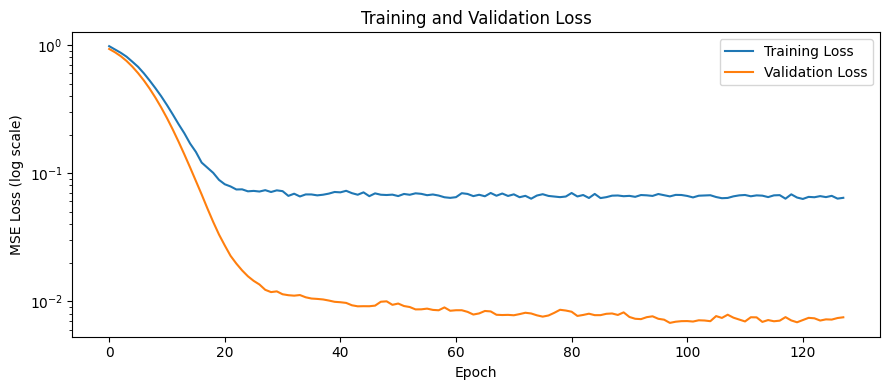

In [8]:
if not model_loaded:
    plt.figure(figsize=(9, 4))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses,   label='Validation Loss')
    plt.yscale('log')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss (log scale)')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Learning curves not available for a loaded model.")

## 10. Prediction and Reconstruction

We evaluate the model on the held-out test set. The predicted coefficients $\hat{\mathbf{a}}$ are:
1. **inverse-transformed** from standardised scale back to physical scale,
2. **lifted** to pixel space via $\tilde{\mathbf{x}} = \boldsymbol{\Phi}\,\hat{\mathbf{a}}$.

We show a grid of 4 consecutive time steps comparing the network prediction to the ground truth.

In [9]:
model.eval()
with torch.no_grad():
    prediction = model(X_test).cpu().numpy()
print(f"Raw prediction shape: {prediction.shape}")

prediction    = scaler_out.inverse_transform(prediction)

predicted_frames = (phi @ prediction.T).T.reshape(-1, H, W)
true_frames      = (phi @ output_test.T).T.reshape(-1, H, W)

print(f"Predicted frames shape : {predicted_frames.shape}")
print(f"True frames shape      : {true_frames.shape}")

Raw prediction shape: (26, 35)
Predicted frames shape : (26, 128, 256)
True frames shape      : (26, 128, 256)


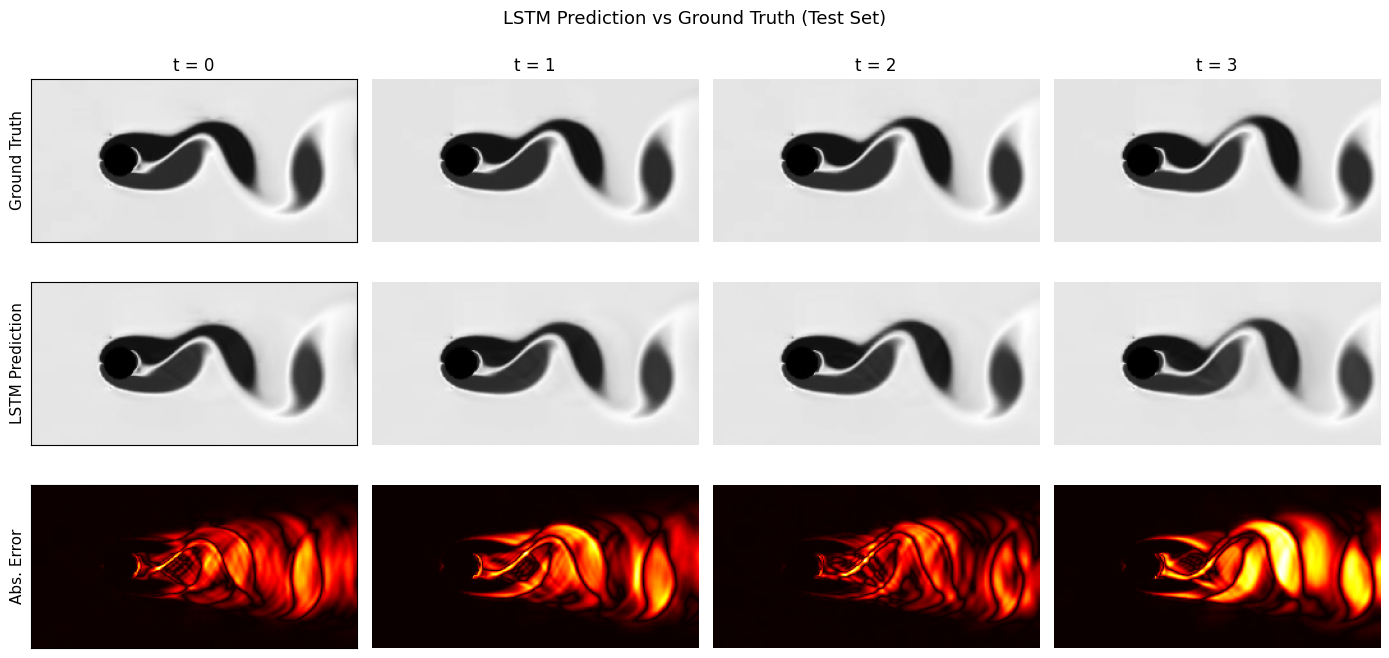

In [10]:
n_show = 4
fig, axes = plt.subplots(3, n_show, figsize=(14, 7))
row_labels = ['Ground Truth', 'LSTM Prediction', 'Abs. Error']

for col in range(n_show):
    err = np.abs(predicted_frames[col] - true_frames[col])
    axes[0, col].imshow(true_frames[col],      cmap='gray')
    axes[1, col].imshow(predicted_frames[col], cmap='gray')
    axes[2, col].imshow(err,                   cmap='hot')
    axes[0, col].set_title(f't = {col}')
    for row in range(3):
        axes[row, col].axis('off')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=11)
    axes[row, 0].axis('on')
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

plt.suptitle('LSTM Prediction vs Ground Truth (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
mse = np.mean((predicted_frames - true_frames)**2)
mae = np.mean(np.abs(predicted_frames - true_frames))
print(f"Test MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")

Test MSE: 9.7874
Test MAE: 1.4917


## 11. Summary and Key Takeaways

| | |
|---|---|
| **Dimensionality reduction** | SVD with $r = 35$ modes |
| **Architecture** | LSTM(128) + Dropout(0.2) + Linear($r$) |
| **Training** | Adam, MSE loss, early stopping (patience = 30) |
| **Input** | Standardised POD coefficients $\mathbf{a}(t) \in \mathbb{R}^{35}$ |
| **Output** | Predicted next-step coefficients $\hat{\mathbf{a}}(t+1) \in \mathbb{R}^{35}$ |
| **Reconstruction** | $\tilde{\mathbf{x}} = \boldsymbol{\Phi}\,\hat{\mathbf{a}}$ — lifted back to $\mathbb{R}^{32768}$ |

### Key takeaways

- **Two-stage pipeline**: SVD compresses the flow field; the LSTM learns dynamics in the compressed space. This separation is computationally efficient and physically interpretable.
- **StandardScaler is essential**: the POD coefficients of different modes have vastly different magnitudes (proportional to $\sigma_i$). Without standardisation, the first few modes dominate the loss and the network ignores the rest.
- **LSTM for one-step regression**: even with `seq_len = 1`, the LSTM outperforms a simple MLP on this task because its cell state provides implicit regularisation for quasi-periodic signals.
- **Reconstruction quality** is bounded below by the POD truncation error — the LSTM cannot recover information that was discarded by keeping only $r = 35$ modes.